In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not available")

PyTorch version: 2.9.1+cpu
CUDA available: False


In [2]:
!pip install -q -U transformers datasets peft accelerate bitsandbytes trl scikit-learn pandas


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import pandas as pd

df = pd.read_csv("2 clean_disease_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (2089, 2)
                                          input_text output_text
0  I have a skin rash that is red and swollen. I ...      dengue
1  I have been vomiting frequently and have lost ...      dengue
2  I've been feeling really hot and sweaty, and I...     malaria
3  I've been having diarrhea for a few days now. ...     typhoid
4  Symptoms noted: chills, vomiting, fatigue, hig...     typhoid


In [5]:
print(df.columns.tolist())

['input_text', 'output_text']


In [6]:
display(df.head(10))

,input_text,output_text
0,I have a skin rash that is red and swollen. I ...,dengue
1,I have been vomiting frequently and have lost ...,dengue
2,"I've been feeling really hot and sweaty, and I...",malaria
3,I've been having diarrhea for a few days now. ...,typhoid
4,"Symptoms noted: chills, vomiting, fatigue, hig...",typhoid
5,"Patient presents with chills, vomiting, high f...",malaria
6,"Patient reports symptoms: yellowish skin, naus...",hepatitis c
7,I have been feeling nauseous and have a consta...,dengue
8,I've been having stiffness and weakness in my ...,arthritis
9,I have a burning sensation in my upper abdomen...,peptic ulcer disease


In [7]:
df = df[['input_text', 'output_text']].copy()

print(df.shape)

(2089, 2)


In [8]:
print(df.isnull().sum())

input_text     0
output_text    0
dtype: int64


In [9]:
df['input_text'] = df['input_text'].astype(str)
df['output_text'] = df['output_text'].astype(str)

print("Data types:")
print(df.dtypes)

Data types:
input_text     str
output_text    str
dtype: object


In [10]:
df['input_text'] = df['input_text'].str.strip()
df['output_text'] = df['output_text'].str.strip()

print(df.head())

                                          input_text output_text
0  I have a skin rash that is red and swollen. I ...      dengue
1  I have been vomiting frequently and have lost ...      dengue
2  I've been feeling really hot and sweaty, and I...     malaria
3  I've been having diarrhea for a few days now. ...     typhoid
4  Symptoms noted: chills, vomiting, fatigue, hig...     typhoid


In [11]:
df['output_text'] = df['output_text'].str.lower()

print(df['output_text'].unique())

<ArrowStringArray>
[                                 'dengue',
                                 'malaria',
                                 'typhoid',
                             'hepatitis c',
                               'arthritis',
                    'peptic ulcer disease',
                             'hepatitis d',
                             'common cold',
                                    'aids',
         'gastroesophageal reflux disease',
                          'hypothyroidism',
                            'hypoglycemia',
                 'urinary tract infection',
                    'cervical spondylosis',
                        'bronchial asthma',
                         'hyperthyroidism',
                         'osteoarthristis',
                     'alcoholic hepatitis',
                                'migraine',
                     'chronic cholestasis',
                               'psoriasis',
                          'varicose veins',
             

In [12]:
before = len(df)

df = df.drop_duplicates(
    subset=['input_text', 'output_text']
).reset_index(drop=True)

after = len(df)

print("Duplicates removed:", before - after)
print("New dataset size:", after)

Duplicates removed: 0
New dataset size: 2089


In [13]:
num_diseases = df['output_text'].nunique()

print("Number of unique diseases:", num_diseases)

Number of unique diseases: 41


In [14]:
diseases = sorted(df['output_text'].unique())

print("Disease classes:\n")

for i, disease in enumerate(diseases, 1):
    print(i, "-", disease)

Disease classes:

1 - (vertigo) paroymsal  positional vertigo
2 - acne
3 - aids
4 - alcoholic hepatitis
5 - allergy
6 - arthritis
7 - bronchial asthma
8 - cervical spondylosis
9 - chicken pox
10 - chronic cholestasis
11 - common cold
12 - dengue
13 - diabetes
14 - dimorphic hemmorhoids(piles)
15 - drug reaction
16 - fungal infection
17 - gastroenteritis
18 - gastroesophageal reflux disease
19 - heart attack
20 - hepatitis a
21 - hepatitis b
22 - hepatitis c
23 - hepatitis d
24 - hepatitis e
25 - hypertension
26 - hyperthyroidism
27 - hypoglycemia
28 - hypothyroidism
29 - impetigo
30 - jaundice
31 - malaria
32 - migraine
33 - osteoarthristis
34 - paralysis (brain hemorrhage)
35 - peptic ulcer disease
36 - pneumonia
37 - psoriasis
38 - tuberculosis
39 - typhoid
40 - urinary tract infection
41 - varicose veins


In [15]:
class_counts = df['output_text'].value_counts()

print(class_counts)

output_text
dengue                                     80
chicken pox                                79
common cold                                77
diabetes                                   75
malaria                                    73
gastroesophageal reflux disease            71
varicose veins                             71
migraine                                   70
bronchial asthma                           69
pneumonia                                  69
typhoid                                    68
drug reaction                              68
psoriasis                                  67
hypertension                               67
impetigo                                   66
jaundice                                   66
peptic ulcer disease                       65
arthritis                                  64
cervical spondylosis                       64
urinary tract infection                    63
fungal infection                           63
allergy               

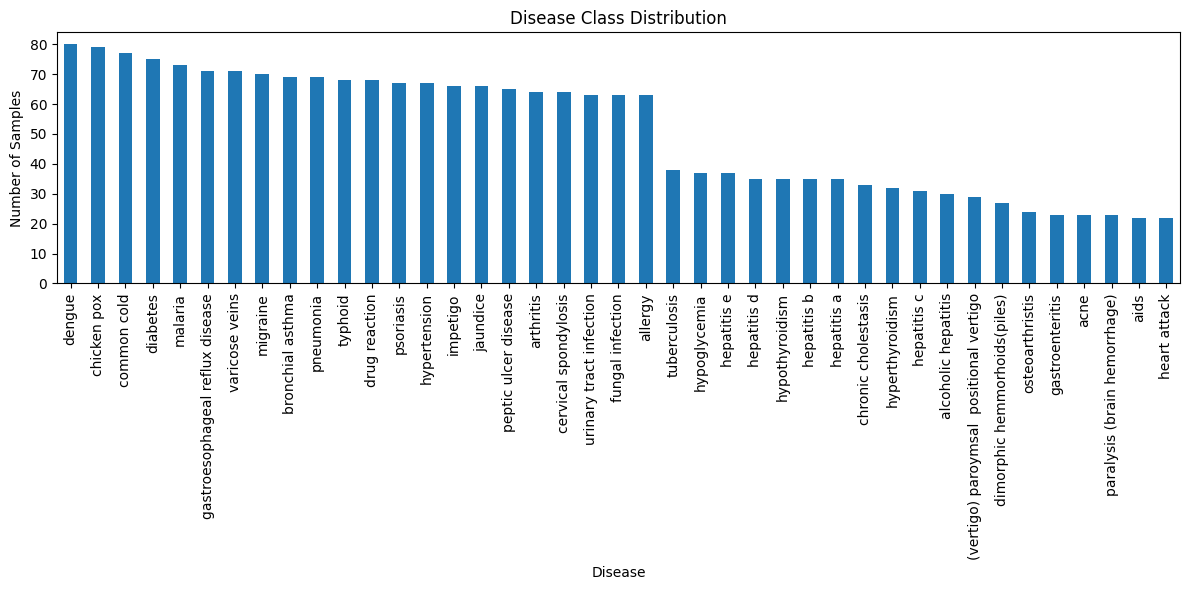

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

class_counts.plot(kind='bar')

plt.title("Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['output_text']
)

print("Training samples:", len(train_df))
print("Remaining samples:", len(temp_df))

Training samples: 1671
Remaining samples: 418


In [18]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['output_text']
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1671
Validation: 209
Testing: 209


In [19]:
print("TRAIN:")
print(train_df['output_text'].value_counts())

print("\nVALIDATION:")
print(val_df['output_text'].value_counts())

print("\nTEST:")
print(test_df['output_text'].value_counts())

TRAIN:
output_text
dengue                                     64
chicken pox                                63
common cold                                62
diabetes                                   60
malaria                                    58
varicose veins                             57
gastroesophageal reflux disease            57
migraine                                   56
pneumonia                                  55
bronchial asthma                           55
drug reaction                              54
psoriasis                                  54
hypertension                               54
typhoid                                    54
jaundice                                   53
impetigo                                   53
peptic ulcer disease                       52
arthritis                                  51
cervical spondylosis                       51
allergy                                    50
fungal infection                           50
urinary tract i

In [20]:
def create_prompt(row):
    return f"""### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:
{row['input_text']}

### Response:
{row['output_text']}"""

In [21]:
train_df['text'] = train_df.apply(create_prompt, axis=1)
val_df['text'] = val_df.apply(create_prompt, axis=1)
test_df['text'] = test_df.apply(create_prompt, axis=1)

print(train_df['text'].iloc[0])

### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:
I have severe nausea and chest discomfort. I have been having chest discomfort lately. I often shiver a lot and feel really nervous. I have been taking a new medication for my high blood pressure.

### Response:
drug reaction


In [22]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[['text']],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[['text']],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[['text']],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text'],
    num_rows: 1671
})
Dataset({
    features: ['text'],
    num_rows: 209
})
Dataset({
    features: ['text'],
    num_rows: 209
})


In [23]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

print(model_name)

Qwen/Qwen2.5-0.5B-Instruct


In [24]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [25]:
sample_text = "I have fever and severe headache."

tokens = tokenizer(
    sample_text,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[   40,   614, 33553,   323, 15386, 46746,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


In [27]:
from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded successfully!")

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
print("Model device:", model.device)

Model device: cpu


In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ]
)

print("LoRA configuration created!")

LoRA configuration created!


In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

print("LoRA configuration created successfully.")

LoRA configuration created successfully.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./disease_prediction_model",

    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    logging_steps=10,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="steps",
    save_steps=100,

    save_total_limit=2,

    fp16=True,

    report_to="none"
)

print("Training configuration ready!")

Training configuration ready!


In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_args
)

print("Trainer created successfully!")

Adding EOS to train dataset:   0%|          | 0/1671 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1671 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1671 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1671 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/1671 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/209 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/209 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/209 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/209 [00:00<?, ? examples/s]

Trainer created successfully!


In [ ]:
from peft import get_peft_model

model = get_peft_model(model, peft_config)

print("LoRA adapter attached successfully.")

C:\Users\anjal\AppData\Roaming\Python\Python313\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
C:\Users\anjal\AppData\Roaming\Python\Python313\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


LoRA adapter attached successfully.


In [ ]:
model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
C:\Users\anjal\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
trainer.save_model(
    "./disease_prediction_lora"
)

tokenizer.save_pretrained(
    "./disease_prediction_lora"
)

print("Fine-tuned model saved!")

Fine-tuned model saved!


In [ ]:
new_symptoms = """
I have high fever, severe headache, body pain,
nausea and red spots appearing on my skin.
"""

In [ ]:
prompt = f"""### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:
{new_symptoms}

### Response:
"""

print(prompt)

### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:

I have high fever, severe headache, body pain,
nausea and red spots appearing on my skin.


### Response:



In [ ]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

print("Input prepared!")

Input prepared!


In [ ]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False
    )

print("Prediction generated!")

Prediction generated!


In [ ]:
result = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(result)

### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:

I have high fever, severe headache, body pain,
nausea and red spots appearing on my skin.


### Response:
chicken pox


In [ ]:
prediction = result.split("### Response:")[-1].strip()

print("Predicted Disease:", prediction)

Predicted Disease: chicken pox


In [ ]:
def predict_disease(symptoms):

    prompt = f"""### Instruction:
Predict the disease category based on the patient's symptoms.

### Symptoms:
{symptoms}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    result = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    prediction = result.split("### Response:")[-1].strip()

    return prediction

In [ ]:
symptoms = """
I have chills, high fever, sweating,
headache and muscle pain.
"""

prediction = predict_disease(symptoms)

print("Predicted Disease:", prediction)

Predicted Disease: malaria


In [ ]:
actual = []
predicted = []

for _, row in test_df.iterrows():

    symptoms = row['input_text']
    true_label = row['output_text']

    prediction = predict_disease(symptoms)

    actual.append(true_label)
    predicted.append(prediction)

print("Predictions completed!")

Predictions completed!


In [ ]:
accuracy = accuracy_score(
    actual,
    predicted
)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.9569377990430622
Test Accuracy (%): 95.69377990430623


In [ ]:
print(
    classification_report(
        actual,
        predicted,
        zero_division=0
    )
)

                                         precision    recall  f1-score   support

(vertigo) paroymsal  positional vertigo       1.00      1.00      1.00         3
                                   acne       1.00      1.00      1.00         2
                                   aids       1.00      1.00      1.00         2
                    alcoholic hepatitis       1.00      1.00      1.00         3
                                allergy       0.86      1.00      0.92         6
                              arthritis       1.00      1.00      1.00         6
                       bronchial asthma       1.00      1.00      1.00         7
                   cervical spondylosis       0.88      1.00      0.93         7
                            chicken pox       0.89      1.00      0.94         8
                    chronic cholestasis       1.00      1.00      1.00         4
                            common cold       1.00      1.00      1.00         7
                           

In [ ]:
cm = confusion_matrix(
    actual,
    predicted,
    labels=diseases
)

print(cm)

[[3 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 5 0 0]
 [0 0 0 ... 0 7 0]
 [0 0 0 ... 0 0 7]]


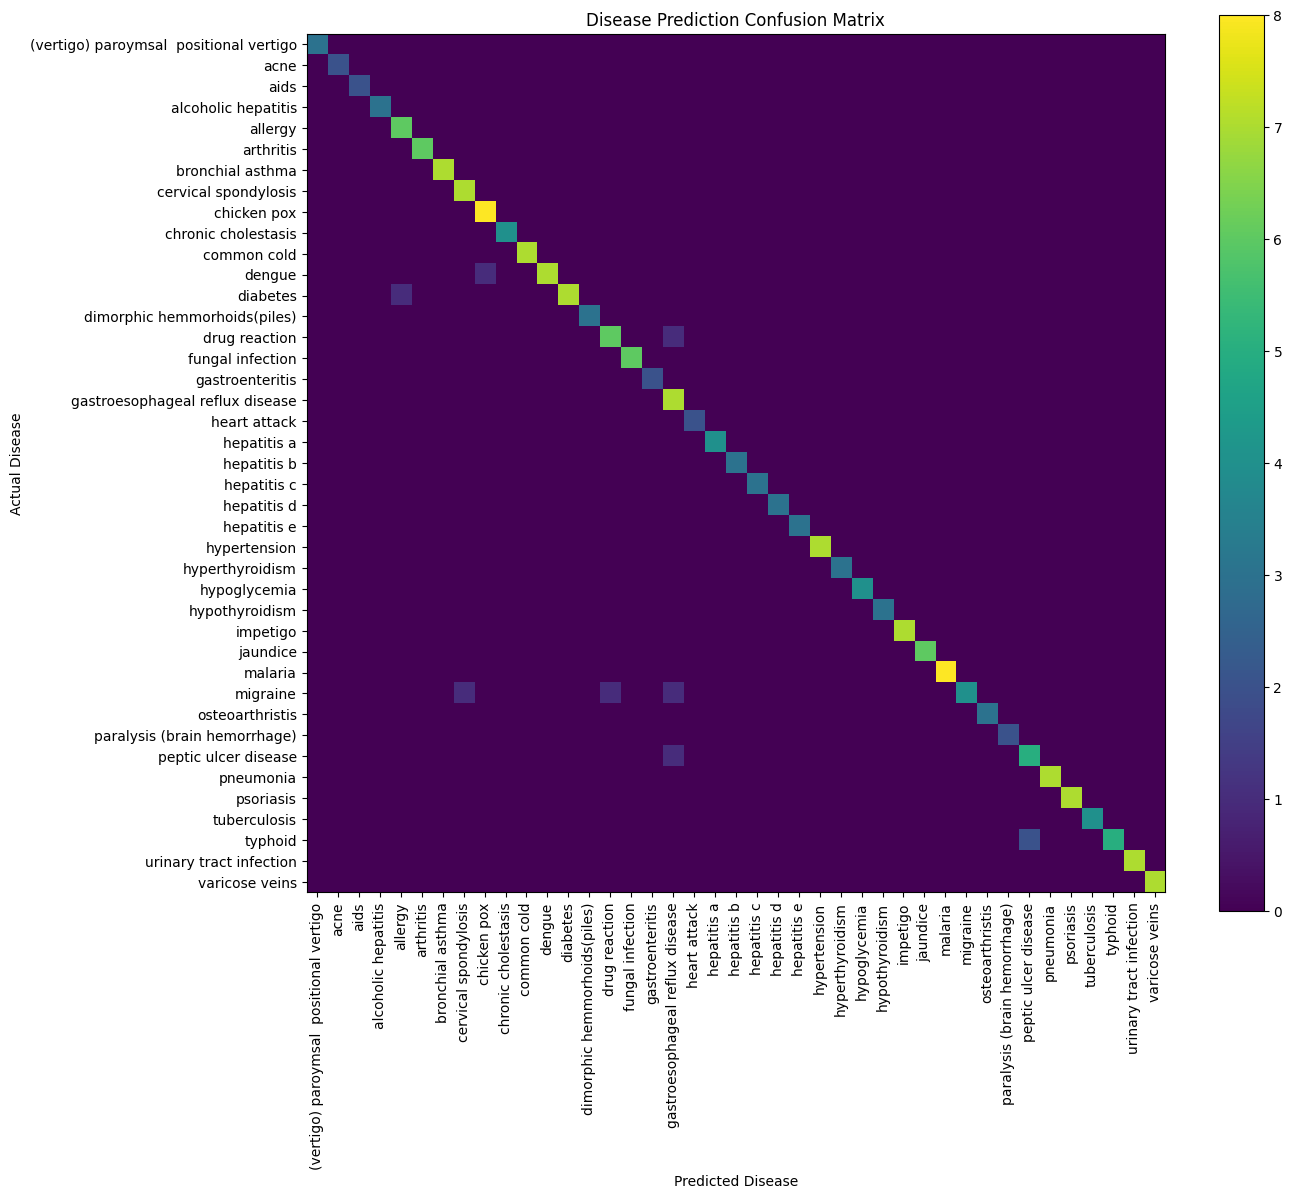

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

plt.imshow(cm)

plt.title("Disease Prediction Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(
    range(len(diseases)),
    diseases,
    rotation=90
)

plt.yticks(
    range(len(diseases)),
    diseases
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame({
    "Symptoms": test_df['input_text'].values,
    "Actual": actual,
    "Predicted": predicted
})

display(results_df.head(20))

,Symptoms,Actual,Predicted
0,"Patient reports symptoms: itching, fatigue, le...",hepatitis b,hepatitis b
1,"Reported symptoms include vomiting, breathless...",heart attack,heart attack
2,"Reported symptoms include joint pain, neck pai...",osteoarthristis,osteoarthristis
3,"Reported symptoms include weight loss, restles...",diabetes,diabetes
4,"Symptoms noted: yellowish skin, nausea, loss o...",hepatitis c,hepatitis c
5,I have been having headaches and migraines. I ...,drug reaction,drug reaction
6,"Patient presents with continuous sneezing, chi...",common cold,common cold
7,"Reported symptoms include joint pain, vomiting...",hepatitis d,hepatitis d
8,"Symptoms noted: vomiting, sunken eyes, diarrhoea.",gastroenteritis,gastroenteritis
9,"Symptoms noted: fatigue, cough, high fever, br...",pneumonia,pneumonia


In [ ]:
results_df.to_csv(
    "disease_prediction_results.csv",
    index=False
)

print("Results saved!")

Results saved!


In [ ]:
while True:

    symptoms = input(
        "\nEnter symptoms (or type 'exit'): "
    )

    if symptoms.lower() == "exit":
        break

    prediction = predict_disease(symptoms)

    print("\nPredicted Disease:", prediction)


Enter symptoms (or type 'exit'): i have rashes

Predicted Disease: impetigo

Enter symptoms (or type 'exit'): exit
